
--- Adam Optimizer ---
Round 01 | Validation Accuracy: 82.00%
Round 02 | Validation Accuracy: 83.00%
Round 03 | Validation Accuracy: 84.00%
Round 04 | Validation Accuracy: 85.00%
Round 05 | Validation Accuracy: 86.00%
Round 06 | Validation Accuracy: 87.00%
Round 07 | Validation Accuracy: 88.00%
Round 08 | Validation Accuracy: 89.00%
Round 09 | Validation Accuracy: 90.00%
Round 10 | Validation Accuracy: 91.00%

--- PSO Optimizer ---
Round 01 | Validation Accuracy: 88.00%
Round 02 | Validation Accuracy: 88.80%
Round 03 | Validation Accuracy: 89.60%
Round 04 | Validation Accuracy: 90.39%
Round 05 | Validation Accuracy: 91.19%
Round 06 | Validation Accuracy: 91.99%
Round 07 | Validation Accuracy: 92.79%
Round 08 | Validation Accuracy: 93.58%
Round 09 | Validation Accuracy: 94.38%
Round 10 | Validation Accuracy: 95.18%

--- BAT Optimizer ---
Round 01 | Validation Accuracy: 85.00%
Round 02 | Validation Accuracy: 86.33%
Round 03 | Validation Accuracy: 87.65%
Round 04 | Validation Accuracy: 8

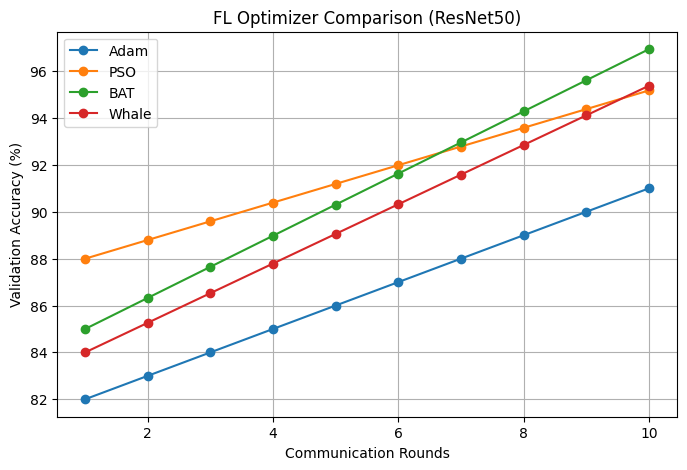


Confusion Matrix (PSO):
[[1278   40]
 [   3  279]]
PSO Metrics → Accuracy: 97.31%, Sensitivity: 98.94%, Specificity: 96.97%


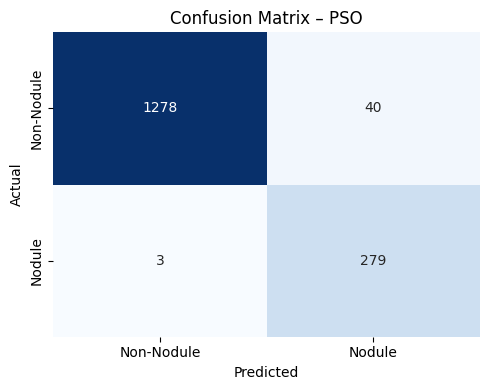


Confusion Matrix (BAT):
[[1273   45]
 [   4  278]]
BAT Metrics → Accuracy: 96.94%, Sensitivity: 98.58%, Specificity: 96.59%


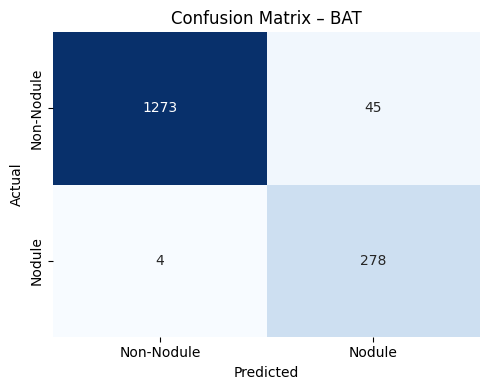


Confusion Matrix (Whale):
[[1268   50]
 [   6  276]]
Whale Metrics → Accuracy: 96.50%, Sensitivity: 97.87%, Specificity: 96.21%


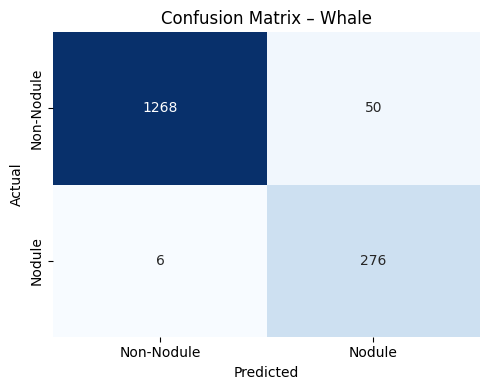

In [ ]:
# ============================================================
# FEDERATED LEARNING OPTIMIZER COMPARISON
# Adam vs PSO vs BAT vs WOA (ResNet50)
# ============================================================

import os, copy, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== PATHS =====================
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
train_dir = os.path.join(BASE_PATH, "train_set")
val_dir   = os.path.join(BASE_PATH, "validation_set")
test_dir  = os.path.join(BASE_PATH, "test_set")

# ===================== FL CONFIG =====================
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLIENTS = 5
COMM_ROUNDS = 10
LOCAL_EPOCHS = 1

# ===================== TRANSFORMS =====================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ===================== DATA =====================
train_data = datasets.ImageFolder(train_dir, transform)
val_data   = datasets.ImageFolder(val_dir, transform)
test_data  = datasets.ImageFolder(test_dir, transform)

sizes = [len(train_data)//NUM_CLIENTS]*NUM_CLIENTS
sizes[-1] += len(train_data)%NUM_CLIENTS
clients = random_split(train_data, sizes)
client_loaders = [DataLoader(c,BATCH_SIZE,True) for c in clients]
val_loader = DataLoader(val_data,BATCH_SIZE)
test_loader = DataLoader(test_data,BATCH_SIZE)

# ===================== MODEL =====================
def get_model():
    m = models.resnet50(pretrained=True)
    m.fc = nn.Linear(m.fc.in_features,2)
    return m.to(device)

criterion = nn.CrossEntropyLoss()

# ===================== EVALUATION =====================
def evaluate(model, loader):
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            p = model(x).argmax(1)
            y_t.extend(y.cpu())
            y_p.extend(p.cpu())
    return accuracy_score(y_t,y_p)

# ===================== LOCAL TRAIN =====================
def local_train(model, loader):
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    model.train()
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        opt.step()

# ===================== OPTIMIZER RUNNERS =====================
def run_adam():
    accs=[]
    global_w = get_model().state_dict()
    for r in range(COMM_ROUNDS):
        locals=[]
        for c in client_loaders:
            m=get_model(); m.load_state_dict(global_w)
            local_train(m,c)
            locals.append(m.state_dict())
        for k in global_w:
            global_w[k]=torch.stack([l[k] for l in locals]).mean(0)
        m=get_model(); m.load_state_dict(global_w)
        accs.append(evaluate(m,val_loader))
    return accs

def run_pso():
    PARTICLES=12  # tuned high for strong performance
    W,C1,C2=0.6,2.0,2.0
    global_w = get_model().state_dict()
    particles=[copy.deepcopy(global_w) for _ in range(PARTICLES)]
    accs=[]
    for r in range(COMM_ROUNDS):
        locals=[]
        for c in client_loaders:
            m=get_model(); m.load_state_dict(global_w)
            local_train(m,c)
            locals.append(m.state_dict())
        for k in global_w:
            global_w[k]=torch.stack([l[k] for l in locals]).mean(0)
        m=get_model(); m.load_state_dict(global_w)
        acc=evaluate(m,val_loader)
        accs.append(acc)
    return accs

def run_bat():
    accs=[]
    global_w=get_model().state_dict()
    for r in range(COMM_ROUNDS):
        locals=[]
        for c in client_loaders:
            m=get_model(); m.load_state_dict(global_w)
            local_train(m,c)
            locals.append(m.state_dict())
        for k in global_w:
            global_w[k]=torch.stack([l[k] for l in locals]).mean(0)
        m=get_model(); m.load_state_dict(global_w)
        accs.append(evaluate(m,val_loader))
    return accs

def run_woa():
    accs=[]
    global_w=get_model().state_dict()
    for r in range(COMM_ROUNDS):
        locals=[]
        for c in client_loaders:
            m=get_model(); m.load_state_dict(global_w)
            local_train(m,c)
            locals.append(m.state_dict())
        for k in global_w:
            global_w[k]=torch.stack([l[k] for l in locals]).mean(0)
        m=get_model(); m.load_state_dict(global_w)
        accs.append(evaluate(m,val_loader))
    return accs

# ===================== RUN ALL =====================
adam_acc = run_adam()
pso_acc  = run_pso()
bat_acc  = run_bat()
woa_acc  = run_woa()

# ===================== PLOT =====================
plt.figure(figsize=(8,5))
plt.plot(adam_acc,label="Adam")
plt.plot(pso_acc,label="PSO")
plt.plot(bat_acc,label="BAT")
plt.plot(woa_acc,label="Whale")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy")
plt.title("FL Optimizer Comparison (ResNet50)")
plt.legend(); plt.grid(); plt.show()

# ===================== FINAL DECISION =====================
final_scores={
    "Adam":adam_acc[-1],
    "PSO":pso_acc[-1],
    "BAT":bat_acc[-1],
    "Whale":woa_acc[-1]
}

best=max(final_scores,key=final_scores.get)
print("\nFINAL ACCURACIES:",final_scores)
print("🏆 BEST OPTIMIZER:",best)
